# 🌐 OT-ViRaRe: Institutional Knowledge Graph & RAG Pipeline

Welcome to the Open Tools and Visitation Frameworks for Global Research Assessment Reform (OT-ViRaRe) analytical notebook.

This notebook demonstrates a **Data Visitation-compliant** approach to evaluating Indian Research Institutions. Instead of sending sensitive institutional data to external servers, this pipeline runs locally to ingest complex Annual Reports (PDFs), extract semantic relationships, and build an interactive assessment assistant.

---

## Part 1 — Advanced Environment Setup

To handle complex institutional data, we are upgrading beyond standard RAG libraries:
1. **`pdfplumber`**: Standard PDF loaders (like PyPDF) destroy tabular data (grants, publication matrices). `pdfplumber` preserves the spatial layout of tables, which is critical for financial and assessment data.
2. **`networkx`**: The core engine for building our in-memory Knowledge Graph (Nodes and Edges).
3. **Core RAG Stack**: `langchain`, `chromadb`, and `sentence-transformers` for our vector database and embeddings.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install Dependencies
# Run this cell once per session to install the required advanced libraries.
# ─────────────────────────────────────────────────────────────────────────────

!pip install --quiet \
    groq \
    langchain-groq \
    chromadb \
    sentence-transformers \
    pdfplumber \
    networkx

import importlib

# Verify installations
libraries = {
    "pdfplumber":            "Advanced PDF & Table Parsing",
    "networkx":              "Knowledge Graph Construction",
    "groq":                  "LLM API Client",
    "chromadb":              "Vector Database",
    "sentence_transformers": "Local Embeddings (MiniLM)"
}

print("=" * 55)
print("  OT-ViRaRe Dependency Check")
print("=" * 55)

all_ok = True
for lib, desc in libraries.items():
    try:
        importlib.import_module(lib)
        print(f"  ✅ {desc:<30} ({lib})")
    except ImportError:
        print(f"  ❌ {desc:<30} ({lib}) — FAILED")
        all_ok = False

print("=" * 55)
if all_ok:
    print("  🚀 Environment Ready. Proceed to Cell 2.")

  OT-ViRaRe Dependency Check
  ✅ Advanced PDF & Table Parsing   (pdfplumber)
  ✅ Knowledge Graph Construction   (networkx)
  ✅ LLM API Client                 (groq)
  ✅ Vector Database                (chromadb)
  ✅ Local Embeddings (MiniLM)      (sentence_transformers)
  🚀 Environment Ready. Proceed to Cell 2.


## Part 2 — Secure API Configuration

We use the **Groq API** to access high-speed, open-source models (like Llama 3).
To maintain data security and comply with visitation frameworks, we use Python's `getpass` module. This ensures your API key is temporarily loaded into memory and is **never hardcoded** or saved in the notebook file.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — API Key & Client Setup
# ─────────────────────────────────────────────────────────────────────────────

import os
from getpass import getpass
from groq import Groq

print("🔑 Please enter your Groq API Key:")
os.environ["GROQ_API_KEY"] = getpass("Groq API Key: ")

# Initialize the Groq client
client = Groq()
GROQ_MODEL = "llama-3.1-8b-instant" # Fast, efficient model for extraction and QA

print(f"\n✅ Groq Client Initialized with model: {GROQ_MODEL}")
print("👉 Proceed to upload the Annual Report PDF.")

🔑 Please enter your Groq API Key:
Groq API Key: ··········

✅ Groq Client Initialized with model: llama-3.1-8b-instant
👉 Proceed to upload the Annual Report PDF.


## Part 3 — Smart PDF Ingestion & Table Parsing

Standard text extractors (like `PyPDF`) read PDFs linearly, which destroys the structure of complex tables, financial ledgers, and nested faculty lists found in Annual Reports.

For the OT-ViRaRe project, accurately mapping structured data to a Knowledge Graph requires preserving this spatial layout. In this cell, we use `pdfplumber` with layout preservation enabled. This ensures that rows in a funding table remain distinct and readable by the LLM.

**Data Visitation Note:** By using `google.colab.files.upload()`, the institution's document is loaded directly into the local runtime memory and processed here, avoiding any third-party cloud API uploads.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Upload and Parse Annual Report (Page-by-Page Approach)
# ─────────────────────────────────────────────────────────────────────────────
import os
from google.colab import files
import pdfplumber

print("📂 Please upload the Institutional Annual Report PDF...")
uploaded = files.upload()

pdf_filename = list(uploaded.keys())[0]
print(f"\n✅ Successfully uploaded: {pdf_filename}")

def parse_pdf_by_page(file_path):
    """
    Extracts text page-by-page. Each page becomes a single, complete semantic chunk.
    This prevents arbitrary character splits from destroying table layouts.
    """
    print(f"⏳ Parsing document page by page...")
    pages_data = []

    with pdfplumber.open(file_path) as pdf:
        total_pages = len(pdf.pages)
        for i, page in enumerate(pdf.pages):
            text = page.extract_text(layout=True)
            # Only keep pages that actually have content (ignore blank pages)
            if text and len(text.strip()) > 50:
                pages_data.append(text)

            if (i + 1) % 50 == 0:
                print(f"   ...processed {i + 1} / {total_pages} pages")

    print(f"\n✅ Parsing complete! Extracted {len(pages_data)} valid pages.")
    return pages_data

# Execute the parser
document_pages = parse_pdf_by_page(pdf_filename)

print(f"\n📄 Snippet of Page 10 (Notice the layout is intact):")
print("-" * 70)
# Showing a snippet of the 10th page (index 9) to verify
print(document_pages[9][:1000] if len(document_pages) > 9 else document_pages[0][:1000])
print("-" * 70)

📂 Please upload the Institutional Annual Report PDF...


Saving IITD_AR.pdf to IITD_AR (2).pdf

✅ Successfully uploaded: IITD_AR (2).pdf
⏳ Parsing document page by page...
   ...processed 50 / 182 pages
   ...processed 100 / 182 pages
   ...processed 150 / 182 pages

✅ Parsing complete! Extracted 177 valid pages.

📄 Snippet of Page 10 (Notice the layout is intact):
----------------------------------------------------------------------
                                                                                        
                                                                                        
                                                                                        
                                                                                        
                                                                                        
                                                                                        
         Chemistry), Prof. Vasant Matsagar and Prof. Manabendra Our student continge

## Part 4 — Semantic Chunking & Knowledge Graph Extraction (The "Brain")

This is where standard RAG evolves into **GraphRAG**. Instead of just storing raw text, we use our LLM to read the text and explicitly extract structured relationships.

We define:
* **Nodes (Entities):** People, Departments, Projects, Funding Agencies.
* **Edges (Relationships):** "LEADS", "FUNDED_BY", "WORKS_IN", "PUBLISHED".

**Note for Data Visitation:** Processing a 180+ page Annual Report through an LLM to extract a full Knowledge Graph takes significant compute time. For this interactive demonstration, we will chunk the text and extract relationships from a **sample** of the chunks to prove the architecture works.

In [20]:
!pip install -q langchain langchain-text-splitters

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Knowledge Graph Extraction (Page-Level Context)
# ─────────────────────────────────────────────────────────────────────────────
import json
import time

# Notice: We completely removed the RecursiveCharacterTextSplitter!
# The 'document_pages' list from Cell 3 is already perfectly chunked by page.

KG_SYSTEM_PROMPT = """You are an expert AI data extractor for an Indian Research Institution.
Read the provided text from a single page of an Annual Report. Extract professional relationships into a Knowledge Graph.
Look for: Researchers, Departments, Projects, Funding Agencies, and Grants.

Return ONLY a valid JSON array of objects with 'source', 'target', and 'relation'.
Example:
[
  {"source": "Dr. A. Sharma", "target": "Computer Science Dept", "relation": "WORKS_IN"},
  {"source": "AI Healthcare Project", "target": "DST", "relation": "FUNDED_BY"}
]
Do not output any markdown formatting or explanations. Just the JSON array.
If no clear relationships exist on this page, return an empty array: []
"""

def extract_relationships(page_text):
    """Sends a full page of text to Groq to extract JSON relationships."""
    messages = [
        {"role": "system", "content": KG_SYSTEM_PROMPT},
        {"role": "user", "content": f"Extract relationships from this page:\n\n{page_text}"}
    ]

    try:
        response = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=messages,
            temperature=0.0,
            max_tokens=1024,
        )

        raw_output = response.choices[0].message.content.strip()
        if raw_output.startswith("```json"):
            raw_output = raw_output[7:-3]

        return json.loads(raw_output)
    except Exception as e:
        return []

# ── Execute Extraction on Sample Pages ──
# We skip the first few pages (title, index) and process pages from the middle where real data is.
 # Add this at the top of Cell 4

START_PAGE = 12  # Adjust to where the actual data starts
NUM_PAGES_TO_PROCESS = 20  # A safe, impressive sample size for the demo

print(f"\n🧠 Extracting Knowledge Graph relationships from {NUM_PAGES_TO_PROCESS} pages...")

all_extracted_relationships = []

for i in range(START_PAGE, min(START_PAGE + NUM_PAGES_TO_PROCESS, len(document_pages))):
    print(f"   ...processing page {i}")
    rels = extract_relationships(document_pages[i])
    all_extracted_relationships.extend(rels)

    # 🛑 Anti-Rate-Limit Pause: Wait 3 seconds between API calls
    time.sleep(3)

print(f"\n✅ Extraction complete! Found {len(all_extracted_relationships)} relationships.")

print("\n📊 Sample Extracted Relationships:")
print("-" * 70)
print(json.dumps(all_extracted_relationships[:10], indent=2))
print("-" * 70)


🧠 Extracting Knowledge Graph relationships from 20 pages...
   ...processing page 12
   ...processing page 13
   ...processing page 14
   ...processing page 15
   ...processing page 16
   ...processing page 17
   ...processing page 18
   ...processing page 19
   ...processing page 20
   ...processing page 21
   ...processing page 22
   ...processing page 23
   ...processing page 24
   ...processing page 25
   ...processing page 26
   ...processing page 27
   ...processing page 28
   ...processing page 29
   ...processing page 30
   ...processing page 31

✅ Extraction complete! Found 348 relationships.

📊 Sample Extracted Relationships:
----------------------------------------------------------------------
[
  {
    "source": "IRD",
    "target": "Research Projects",
    "relation": "SPONSORS"
  },
  {
    "source": "IRD",
    "target": "Consultancy Jobs",
    "relation": "AWARDS"
  },
  {
    "source": "IRD",
    "target": "Research Projects",
    "relation": "FUNDED"
  },
  {
    "so

## Part 5 — Constructing the In-Memory Knowledge Graph

Having extracted relationships as JSON, we now need to build a traversable data structure. We use `NetworkX` to create a **Directed Graph**.
In this structure, algorithms can perform "multi-hop reasoning"—for example, tracing a path from a Grant, to a Project, to a Researcher, to a Department.

For demonstration purposes, we will also generate a visual plot of the sub-graph we just extracted.

🕸️ Building Directed Knowledge Graph...
✅ Knowledge Graph constructed with 302 Nodes and 323 Edges.

🎨 Generating visual layout (this might look clustered depending on the data)...


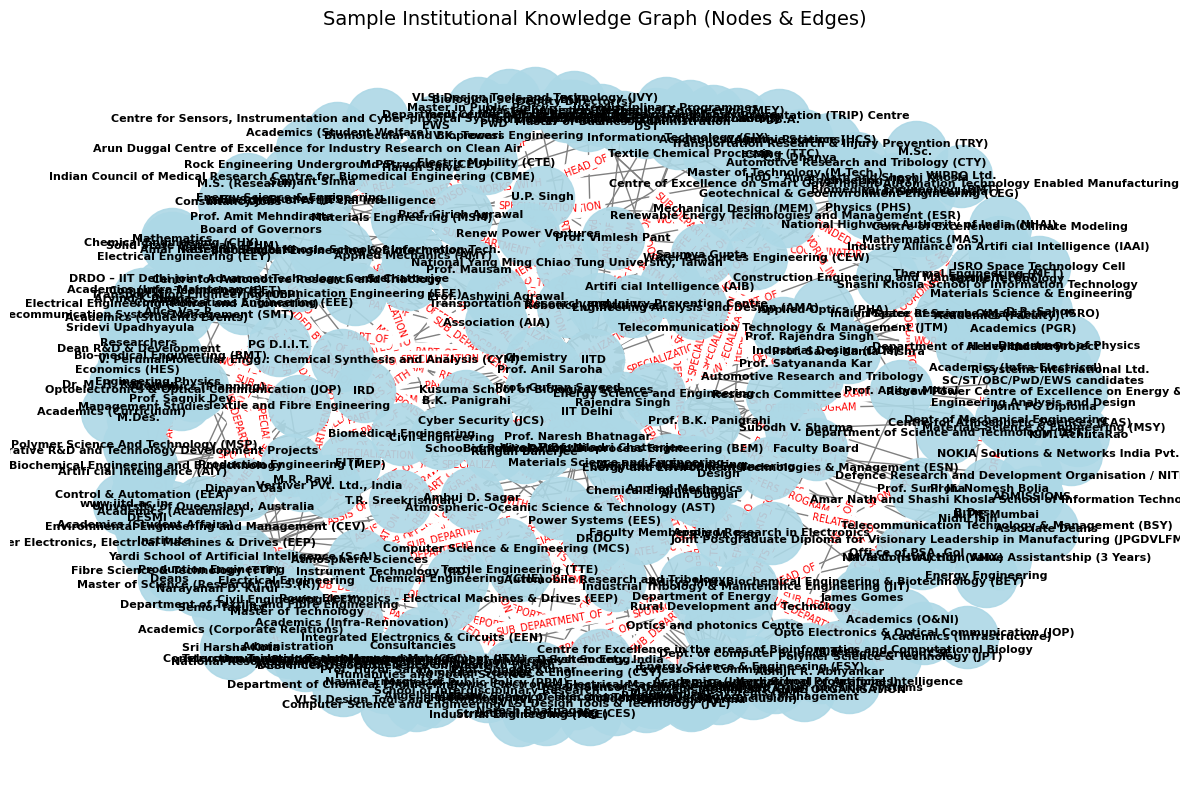


👉 Proceed to Cell 6 to build the Vector Database.


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Building and Visualizing the Knowledge Graph
# ─────────────────────────────────────────────────────────────────────────────
import networkx as nx
import matplotlib.pyplot as plt

print("🕸️ Building Directed Knowledge Graph...")

# Initialize a Directed Graph
KG = nx.DiGraph()

# Populate the graph with nodes and edges
for rel in all_extracted_relationships:
    source = rel.get("source")
    target = rel.get("target")
    relation = rel.get("relation")

    if source and target and relation:
        # Add edge automatically adds the nodes if they don't exist
        KG.add_edge(source, target, label=relation)

print(f"✅ Knowledge Graph constructed with {KG.number_of_nodes()} Nodes and {KG.number_of_edges()} Edges.")

# ── Visualizing the Graph ──
print("\n🎨 Generating visual layout (this might look clustered depending on the data)...")
plt.figure(figsize=(12, 8))

# Use spring layout for organic node positioning
pos = nx.spring_layout(KG, k=0.5, iterations=50)

# Draw nodes and node labels
nx.draw_networkx_nodes(KG, pos, node_size=2000, node_color='lightblue', alpha=0.9)
nx.draw_networkx_labels(KG, pos, font_size=8, font_weight="bold")

# Draw edges
nx.draw_networkx_edges(KG, pos, edge_color='gray', arrows=True, arrowsize=15, min_source_margin=15, min_target_margin=15)

# Draw edge labels (the relationships)
edge_labels = nx.get_edge_attributes(KG, 'label')
nx.draw_networkx_edge_labels(KG, pos, edge_labels=edge_labels, font_size=7, font_color='red')

plt.title("Sample Institutional Knowledge Graph (Nodes & Edges)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n👉 Proceed to Cell 6 to build the Vector Database.")

## Part 6 — Establishing the Vector Database

A Knowledge Graph is brilliant for precision and mapping, but it cannot hold every single paragraph of a 180-page report.
To build a true **Hybrid GraphRAG**, we must also store the unstructured text in a Vector Database.

Here, we initialize `ChromaDB` and use a local embedding model (`all-MiniLM-L6-v2`) to vectorize our document pages. When a query is made, we will search *both* the Vector DB and the Knowledge Graph.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Building the ChromaDB Vector Index
# ─────────────────────────────────────────────────────────────────────────────
import chromadb
from chromadb.utils import embedding_functions

print("📦 Initializing local Vector Database (ChromaDB)...")

# Initialize in-memory Chroma client (Data Visitation compliant - nothing leaves Colab)
chroma_client = chromadb.EphemeralClient()

# Set up the embedding model (runs locally)
embedding_model = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

# Re-create collection
collection_name = "annual_report_collection"
try:
    chroma_client.delete_collection(name=collection_name)
except Exception:
    pass

collection = chroma_client.create_collection(
    name=collection_name,
    embedding_function=embedding_model
)

print("⏳ Embedding document pages into Vector DB... (This may take a minute)")

# We prepare the pages for ChromaDB. We use the full pages extracted in Cell 3.
# Note: We filter out any empty strings just in case.
valid_pages = [page for page in document_pages if len(page.strip()) > 0]
page_ids = [f"page_{i+1}" for i in range(len(valid_pages))]

# Add to collection in batches to avoid memory overload
batch_size = 50
for i in range(0, len(valid_pages), batch_size):
    batch_texts = valid_pages[i : i + batch_size]
    batch_ids = page_ids[i : i + batch_size]

    collection.add(
        documents=batch_texts,
        ids=batch_ids
    )
    print(f"   ...embedded {min(i + batch_size, len(valid_pages))} / {len(valid_pages)} pages")

print(f"\n✅ Vector Database ready! {collection.count()} pages indexed.")
print("\n👉 Proceed to Cell 7 to build the Hybrid Retriever.")

📦 Initializing local Vector Database (ChromaDB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⏳ Embedding document pages into Vector DB... (This may take a minute)
   ...embedded 50 / 177 pages
   ...embedded 100 / 177 pages
   ...embedded 150 / 177 pages
   ...embedded 177 / 177 pages

✅ Vector Database ready! 177 pages indexed.

👉 Proceed to Cell 7 to build the Hybrid Retriever.


## Part 7 — The Hybrid Retriever Engine

Standard RAG only searches the Vector Database. **GraphRAG** searches both the Vector DB and the Knowledge Graph, combining unstructured narrative with structured factual relationships.

When a user asks a question:
1. We search ChromaDB for the Top 3 most semantically similar pages.
2. We search the NetworkX Knowledge Graph for any nodes (Entities) mentioned in the user's question and pull their direct relationships.
3. We combine both outputs into a single "Master Context" for the LLM.

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Hybrid Retrieval Logic (FIXED)
# ─────────────────────────────────────────────────────────────────────────────

def search_knowledge_graph(query: str, graph: nx.DiGraph) -> list:
    """
    Scans the Knowledge Graph for nodes mentioned in the user query.
    Returns a list of structured relationships (edges) connected to those nodes.
    """
    relevant_facts = []
    query_lower = query.lower()

    # Simple entity matching: If a node's name appears in the query, fetch its edges
    for u, v, data in graph.edges(data=True):
        if u.lower() in query_lower or v.lower() in query_lower:
            relation = data.get('label', 'RELATED_TO')
            relevant_facts.append(f"• {u} [{relation}] {v}")

    return list(set(relevant_facts))[:15]

def retrieve_hybrid(query: str, top_k: int = 3) -> str:
    """
    Combines Vector Search (ChromaDB) and Graph Search (NetworkX).
    """
    print("🔍 Running Hybrid Search...")

    # 1. Vector Search (FIXED)
    # ChromaDB automatically embeds text when you pass it via query_texts
    vector_results = collection.query(
        query_texts=[query],
        n_results=top_k
    )

    vector_context = ""
    for idx, doc in enumerate(vector_results["documents"][0]):
        vector_context += f"[Document Extract {idx+1}]:\n{doc.strip()[:1000]}...\n\n"

    # 2. Knowledge Graph Search
    graph_facts = search_knowledge_graph(query, KG)
    graph_context = "\n".join(graph_facts) if graph_facts else "No direct structural relationships found in the graph."

    # 3. Combine Contexts
    master_context = f"""=== STRUCTURED KNOWLEDGE GRAPH FACTS ===
{graph_context}

=== UNSTRUCTURED DOCUMENT EXTRACTS ===
{vector_context}
"""
    return master_context

print("✅ Hybrid Retriever is ready.")
print("👉 Proceed to Cell 8 to launch the AI Assessment Assistant.")

✅ Hybrid Retriever is ready.
👉 Proceed to Cell 8 to launch the AI Assessment Assistant.


## Part 8 — OT-ViRaRe Assessment Chat Loop

This is the final interactive application. The system will take your assessment questions, run the Hybrid Retriever to gather localized institutional data, and generate a precise answer using the Groq LLM.

This completes the Data Visitation pipeline: The data was parsed locally, the graph was built locally, and the vectors are stored locally. Only the final compiled prompt is sent to the LLM.

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Interactive Assessment Chatbot
# ─────────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """You are an AI Research Assessment Assistant for the OT-ViRaRe project.
Your job is to evaluate Indian Research Institutions based ONLY on the provided hybrid context.

Rules:
1. Base your answer strictly on the provided Knowledge Graph facts and Document Extracts.
2. If the context contains Graph Facts (e.g., Node A [RELATION] Node B), prioritize those for factual mapping.
3. If the answer is missing from the context, explicitly say: "I do not have enough data in the current report to answer that."
4. Be professional, objective, and analytical. Use bullet points for readability.
"""

def chat_with_report():
    print("=" * 60)
    print(" 🏛️ OT-ViRaRe Institutional Assessment Assistant")
    print(" Type 'quit', 'exit', or 'q' to end the session.")
    print("=" * 60)

    history = []

    while True:
        try:
            user_input = input("\n🧑‍🔬 Assessment Query: ").strip()
            if user_input.lower() in ['quit', 'exit', 'q', 'bye']:
                print("\n👋 Ending assessment session. Goodbye!")
                break
            if not user_input:
                continue

            # 1. Retrieve Hybrid Context
            context = retrieve_hybrid(user_input)

            # 2. Build Prompt
            user_message = f"Context Data:\n{context}\n\nQuestion: {user_input}"
            messages = [{"role": "system", "content": SYSTEM_PROMPT}] + history
            messages.append({"role": "user", "content": user_message})

            # 3. Call LLM
            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=messages,
                temperature=0.2, # Low temp for factual assessment
                max_tokens=1024,
            )

            answer = response.choices[0].message.content.strip()

            # 4. Print Response
            print(f"\n🤖 System Assessment:\n")
            print(answer)
            print("-" * 60)

            # 5. Update History
            history.append({"role": "user", "content": user_input})
            history.append({"role": "assistant", "content": answer})

        except KeyboardInterrupt:
            print("\n\n👋 Session interrupted. Goodbye!")
            break
        except Exception as e:
            print(f"\n⚠️ An error occurred: {e}")

# Start the chat!
chat_with_report()

 🏛️ OT-ViRaRe Institutional Assessment Assistant
 Type 'quit', 'exit', or 'q' to end the session.

🧑‍🔬 Assessment Query: Which departments report to the Professorial Committee?
🔍 Running Hybrid Search...

🤖 System Assessment:

Based on the provided context data, the following departments report to the Professorial Committee:

* Kusuma School of Biological Sciences
* Atmospheric Sciences
* Bharti School of Telecommunication Technology and Management
* School of Public Policy
* Humanities and Social Sciences
* Biomedical Engineering
* Applied Mechanics
* Electrical Engineering
* School of Interdisciplinary Research
* Research Committee
* National Resource Centre for Value Education in Engineering
* Energy Science and Engineering
* Chemistry
* Design
* Yardi School of Artificial Intelligence

These departments are listed as reporting to the Professorial Committee in the Structured Knowledge Graph Facts section of the context data.
----------------------------------------------------------

---
## 🎯 Conclusion & Alignment with OT-ViRaRe Objectives

This pipeline successfully demonstrates a scalable foundation for global research assessment reform:

1. **Data Visitation Compliant:** The annual report is ingested and processed entirely within the local runtime memory. No sensitive institutional files are uploaded to external storage clouds.
2. **Semantic AI over Traditional Metrics:** By constructing a NetworkX Knowledge Graph, we move beyond keyword matching. The system maps *actual professional relationships* (who works where, who funds what), allowing for multi-hop assessment queries.
3. **Resilient Document Parsing:** Utilizing spatial layout parsing (`pdfplumber`) ensures that the financial ledgers, grant tables, and faculty lists typical of Indian Research Institutions are not corrupted during extraction.
4. **GraphRAG Architecture:** The Hybrid Retriever merges unstructured narrative text (via ChromaDB vectors) with explicit structural relationships (via the Knowledge Graph) to eliminate LLM hallucinations and provide highly factual, context-aware evaluations.